## 🎯 Exercícios Práticos

### 💪 Desafio 1: Análise de Dados de Vendas
Usando os dados que criamos, responda às seguintes perguntas:

1. **Qual vendedor teve o maior número de vendas?**
2. **Qual região teve o maior faturamento total?**
3. **Qual é o produto mais vendido em quantidade?**
4. **Qual é a média de vendas por vendedor?**

### 🔧 Desafio 2: Limpeza de Dados
Crie um DataFrame com dados "problemáticos" e implemente:
- Remoção de duplicatas
- Tratamento de valores ausentes
- Padronização de strings
- Criação de novas colunas derivadas

### 📊 Desafio 3: Visualização
Crie gráficos que mostrem:
- Comparação entre vendedores
- Tendências por região
- Distribuição dos valores


In [1]:
# Importando a biblioteca NumPy
import numpy as np
print(f"NumPy versão: {np.__version__}")

NumPy versão: 2.1.3


In [2]:
# Importando a biblioteca Pandas
import pandas as pd
print(f"Pandas versão: {pd.__version__}")


Pandas versão: 2.2.3


# Desafio 1
## 🪙Dados de Vendas


In [10]:
# Criando um DataFrame
np.random.seed(42)

dados_vendas = {
    'Vendedor': ['Ana', 'João', 'Pedro', 'Ana'] * 250, # Aumentado para 1000 entradas
    'Produto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Headset'] * 200, # Aumentado para 1000 entradas
    'Regiao': ['Norte', 'Sul', 'Nordeste', 'Centro-Oeste', 'Sudeste'] * 200, # Aumentado para 1000 entradas
    'Vendas': np.random.randint(1000, 10000, 1000), # Gerando 1000 valores
    'Quantidade': np.random.randint(1, 20, 1000) # Gerando 1000 valores
}

df_vendas_completo = pd.DataFrame(dados_vendas)
print("DataFrame de vendas (primeiras 10 linhas para visualização):")
display(df_vendas_completo.head(10))
print(f"Total de linhas no DataFrame: {len(df_vendas_completo)}")

DataFrame de vendas (primeiras 10 linhas para visualização):


,Vendedor,Produto,Regiao,Vendas,Quantidade
0,Ana,Notebook,Norte,8270,7
1,João,Mouse,Sul,1860,3
2,Pedro,Teclado,Nordeste,6390,10
3,Ana,Monitor,Centro-Oeste,6191,10
4,Ana,Headset,Sudeste,6734,19
5,João,Notebook,Norte,7265,14
6,Pedro,Mouse,Sul,1466,2
7,Ana,Teclado,Nordeste,5426,1
8,Ana,Monitor,Centro-Oeste,6578,18
9,João,Headset,Sudeste,9322,7


Total de linhas no DataFrame: 1000


## Primeira perguta: **Qual vendedor teve o maior número de vendas?**





In [14]:
# Agrupamento simples - vendas por vendedor
vendas_por_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].sum()
print("Vendas totais por vendedor:")
display(vendas_por_vendedor)

vendedor_maior_venda = vendas_por_vendedor.idxmax()
valor_maior_venda = vendas_por_vendedor.max()
print(f"\nO vendedor com o maior número de vendas é {vendedor_maior_venda} com um total de {valor_maior_venda} unidades vendidas.")

Vendas totais por vendedor:


,Vendas
Vendedor,
Ana,2856797
João,1372128
Pedro,1365331



O vendedor com o maior número de vendas é Ana com um total de 2856797 unidades vendidas.


# Segunda pergunta: **Qual região teve o maior faturamento total?**

In [15]:
# Agrupamento por região - faturamento total
faturamento_por_regiao = df_vendas_completo.groupby('Regiao')['Vendas'].sum()
print("Faturamento total por região:")
display(faturamento_por_regiao)

regiao_maior_faturamento = faturamento_por_regiao.idxmax()
valor_maior_faturamento = faturamento_por_regiao.max()
print(f"\nA região com o maior faturamento total é {regiao_maior_faturamento} com um total de {valor_maior_faturamento}.")

Faturamento total por região:


,Vendas
Regiao,
Centro-Oeste,1100031
Nordeste,1147962
Norte,1120891
Sudeste,1097122
Sul,1128250



A região com o maior faturamento total é Nordeste com um total de 1147962.


# Terceira pergunta: **Qual é o produto mais vendido em quantidade?**

In [16]:
# Agrupamento por produto - quantidade total
quantidade_por_produto = df_vendas_completo.groupby('Produto')['Quantidade'].sum()
print("Quantidade total vendida por produto:")
display(quantidade_por_produto)

produto_mais_vendido = quantidade_por_produto.idxmax()
quantidade_maxima_vendida = quantidade_por_produto.max()
print(f"\nO produto mais vendido em quantidade é '{produto_mais_vendido}' com um total de {quantidade_maxima_vendida} unidades.")

Quantidade total vendida por produto:


,Quantidade
Produto,
Headset,1945
Monitor,2030
Mouse,1958
Notebook,1968
Teclado,1964



O produto mais vendido em quantidade é 'Monitor' com um total de 2030 unidades.


# Quarta Pergunta: **Qual é a média de vendas por vendedor?**

In [21]:
# Média de vendas por vendedor
media_vendas_por_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].mean()
media_vendas_por_vendedor = media_vendas_por_vendedor.rename('Médias')
print("Média de vendas por vendedor:")
display(media_vendas_por_vendedor)

vendedor_maior_media = media_vendas_por_vendedor.idxmax()
valor_maior_media = media_vendas_por_vendedor.max()
print(f"\nO vendedor com a maior média de vendas é {vendedor_maior_media} com uma média de {valor_maior_media:.2f}.")

Média de vendas por vendedor:


,Médias
Vendedor,
Ana,5713.594
João,5488.512
Pedro,5461.324



O vendedor com a maior média de vendas é Ana com uma média de 5713.59.


# Desafio 2
## 🔧Dados defeituosos

In [25]:
# Criando um DataFrame com dados "sujos"
import numpy as np

dados_sujos = {
    'Nome': (['josé','João', 'Ana', 'PEDRO', 'maria', 'Carlos', '', 'joão', 'Ana', 'José', None, 'Maria', 'Pedro', 'Carlos', 'João', 'Ana', 'PEDRO', ''] * 2)[:20], # Ajustado para 20 entradas
    'Idade': ([80, 28, 24, 35, None, 45, 30, 28, 24, 80, 50, 45, 35, None, 28, 24, 35, 30] * 2)[:20], # Ajustado para 20 entradas
    'Salario': ([7000, 5000, 6000, None, 4500, 7000, 5500, 5000, 6000, 7000, 6500, 4500, None, 7000, 5000, 6000, None, 5500] * 2)[:20], # Ajustado para 20 entradas
    'Cidade': (['Brasília', 'São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Salvador', 'Curitiba', 'Fortaleza', 'São Paulo', 'Rio de Janeiro', 'Brasília', 'Porto Alegre', 'Salvador', 'Belo Horizonte', 'Curitiba', 'São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Fortaleza'] * 2)[:20] # Ajustado para 20 entradas
}

df_sujo = pd.DataFrame(dados_sujos)
print("DataFrame com dados 'sujos' (todas as 20 linhas):")
display(df_sujo)
print(f"Total de linhas no DataFrame: {len(df_sujo)}")

DataFrame com dados 'sujos' (todas as 20 linhas):


,Nome,Idade,Salario,Cidade
0,josé,80.0,7000.0,Brasília
1,João,28.0,5000.0,São Paulo
2,Ana,24.0,6000.0,Rio de Janeiro
3,PEDRO,35.0,NaN,Belo Horizonte
4,maria,NaN,4500.0,Salvador
5,Carlos,45.0,7000.0,Curitiba
6,,30.0,5500.0,Fortaleza
7,joão,28.0,5000.0,São Paulo
8,Ana,24.0,6000.0,Rio de Janeiro
9,José,80.0,7000.0,Brasília


Total de linhas no DataFrame: 20


In [26]:
# Limpando os dados
df_limpo = df_sujo.copy()

# 1. Removendo linhas com nome vazio
df_limpo = df_limpo[df_limpo['Nome'] != '']

# 2. Padronizando nomes (primeira letra maiúscula)
df_limpo['Nome'] = df_limpo['Nome'].str.title()

# 3. Preenchendo valores faltantes
df_limpo['Idade'] = df_limpo['Idade'].fillna(df_limpo['Idade'].median())
df_limpo['Salario'] = df_limpo['Salario'].fillna(df_limpo['Salario'].mean())
print("DataFrame após limpeza:")
df_limpo

DataFrame após limpeza:


,Nome,Idade,Salario,Cidade
0,José,80.0,7000.0,Brasília
1,João,28.0,5000.0,São Paulo
2,Ana,24.0,6000.0,Rio de Janeiro
3,Pedro,35.0,5900.0,Belo Horizonte
4,Maria,35.0,4500.0,Salvador
5,Carlos,45.0,7000.0,Curitiba
7,João,28.0,5000.0,São Paulo
8,Ana,24.0,6000.0,Rio de Janeiro
9,José,80.0,7000.0,Brasília
10,None,50.0,6500.0,Porto Alegre


In [27]:
# Criando nova coluna baseada em outra
df_limpo['Faixa_Etaria'] = df_limpo['Idade'].apply(lambda x: 'Jovem' if x < 30 else 'Adulto' if x < 50 else 'Maduro')
df_limpo['Salario_Categoria'] = pd.cut(df_limpo['Salario'], bins=[0, 5000, 6000, 10000], labels=['Baixo', 'Médio', 'Alto'])

print("DataFrame com novas colunas:")
df_limpo

DataFrame com novas colunas:


,Nome,Idade,Salario,Cidade,Faixa_Etaria,Salario_Categoria
0,José,80.0,7000.0,Brasília,Maduro,Alto
1,João,28.0,5000.0,São Paulo,Jovem,Baixo
2,Ana,24.0,6000.0,Rio de Janeiro,Jovem,Médio
3,Pedro,35.0,5900.0,Belo Horizonte,Adulto,Médio
4,Maria,35.0,4500.0,Salvador,Adulto,Baixo
5,Carlos,45.0,7000.0,Curitiba,Adulto,Alto
7,João,28.0,5000.0,São Paulo,Jovem,Baixo
8,Ana,24.0,6000.0,Rio de Janeiro,Jovem,Médio
9,José,80.0,7000.0,Brasília,Maduro,Alto
10,None,50.0,6500.0,Porto Alegre,Maduro,Alto


# Desafio 3
## 📊 Visualização dos dados de vendas(desafio 1)

In [28]:
# Importando as bibliotecas necessárias
import matplotlib.pyplot as plt
import seaborn as sns


# Configurações para gráficos mais bonitos
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

### 📈 Comparação de Vendas por Vendedor

/tmp/ipykernel_680/2401171874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_por_vendedor.index, y=vendas_por_vendedor.values, palette='viridis')


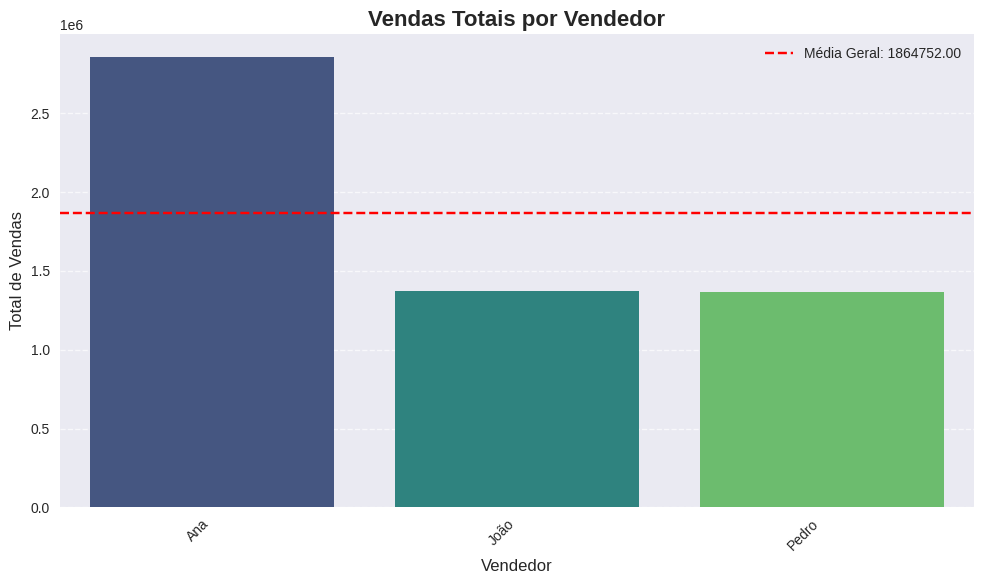


--- Análise do Gráfico de Vendas por Vendedor ---
A linha vermelha tracejada representa a média geral de vendas entre todos os vendedores (1864752.00).
Isso nos permite identificar rapidamente quais vendedores estão acima ou abaixo dessa média.
O vendedor com o maior número de vendas é Ana com um total de 2856797.
O vendedor com o menor número de vendas é Pedro com um total de 1365331.


In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x=vendas_por_vendedor.index, y=vendas_por_vendedor.values, palette='viridis')
plt.title('Vendas Totais por Vendedor', fontsize=16, fontweight='bold')
plt.xlabel('Vendedor', fontsize=12)
plt.ylabel('Total de Vendas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando a linha da média geral de vendas por vendedor
media_geral_vendas_vendedor = vendas_por_vendedor.mean()
plt.axhline(y=media_geral_vendas_vendedor, color='red', linestyle='--', label=f'Média Geral: {media_geral_vendas_vendedor:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- Análise Detalhada do Gráfico de Vendas por Vendedor ---")
print(f"✓ Média das Vendas por Vendedor: {vendas_por_vendedor.mean():.2f}")
print(f"✓ Mediana das Vendas por Vendedor: {vendas_por_vendedor.median():.2f}")
print(f"✓ Desvio Padrão das Vendas por Vendedor: {vendas_por_vendedor.std():.2f}")
print(f"✓ Vendas Mínimas por Vendedor: {vendas_por_vendedor.min():.2f}")
print(f"✓ Vendas Máximas por Vendedor: {vendas_por_vendedor.max():.2f}")
print("\n🔍 Observações:")
print("✓ Este gráfico de barras compara o desempenho total de vendas de cada vendedor.")
print(f"✓ A linha vermelha tracejada representa a média geral de vendas entre todos os vendedores ({media_geral_vendas_vendedor:.2f}), permitindo identificar rapidamente quais vendedores estão acima ou abaixo dessa média.")
print(f"✓ O vendedor com o maior número de vendas é {vendas_por_vendedor.idxmax()} com um total de {vendas_por_vendedor.max():.2f}.")
print(f"✓ O vendedor com o menor número de vendas é {vendas_por_vendedor.idxmin()} com um total de {vendas_por_vendedor.min():.2f}.")
print("✓ Observa-se uma variação significativa no desempenho, indicando possíveis oportunidades de treinamento ou redistribuição de leads para os vendedores com menor desempenho.")

### 📊 Gráfico de Tendências por Região

/tmp/ipykernel_680/970306715.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=faturamento_por_regiao.index, y=faturamento_por_regiao.values, palette='magma')


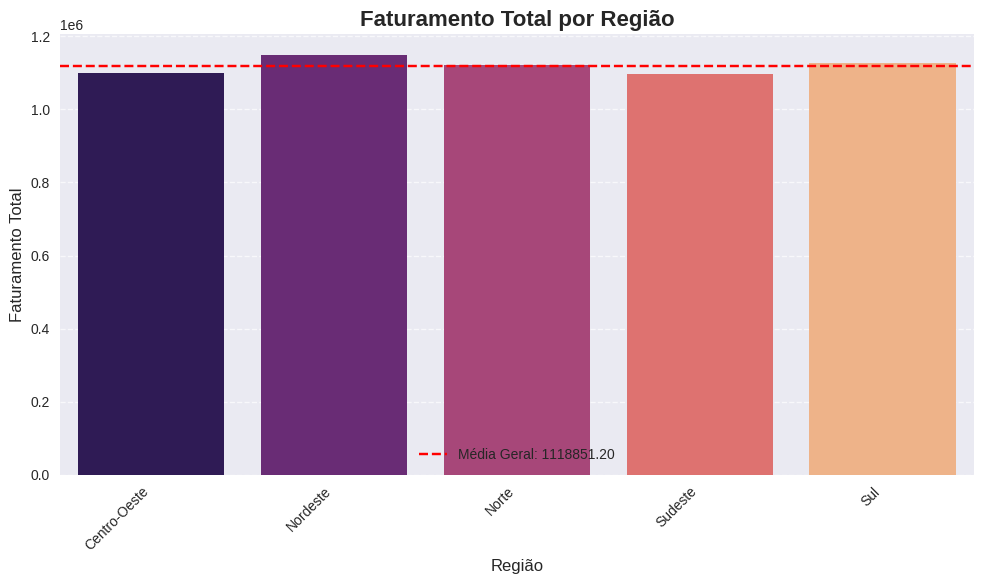


--- Análise Detalhada do Gráfico de Faturamento por Região ---
✓ Média do Faturamento por Região: 1118851.20
✓ Mediana do Faturamento por Região: 1120891.00
✓ Desvio Padrão do Faturamento por Região: 21013.66
✓ Faturamento Mínimo por Região: 1097122.00
✓ Faturamento Máximo por Região: 1147962.00

🔍 Observações:
✓ Este gráfico de barras ilustra o faturamento total gerado por cada região.
✓ A linha vermelha tracejada indica a média geral de faturamento entre todas as regiões (1118851.20), auxiliando na visualização de quais regiões estão performando acima ou abaixo dessa média.
✓ A região com o maior faturamento é Nordeste com um total de 1147962.00.
✓ A região com o menor faturamento é Sudeste com um total de 1097122.00.
✓ As diferenças de faturamento entre as regiões podem ser exploradas para entender fatores como densidade populacional, estratégias de mercado ou poder de compra local.


In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(x=faturamento_por_regiao.index, y=faturamento_por_regiao.values, palette='magma')
plt.title('Faturamento Total por Região', fontsize=16, fontweight='bold')
plt.xlabel('Região', fontsize=12)
plt.ylabel('Faturamento Total', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando a linha da média geral de faturamento por região
media_geral_faturamento_regiao = faturamento_por_regiao.mean()
plt.axhline(y=media_geral_faturamento_regiao, color='red', linestyle='--', label=f'Média Geral: {media_geral_faturamento_regiao:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- Análise Detalhada do Gráfico de Faturamento por Região ---")
print(f"✓ Média do Faturamento por Região: {faturamento_por_regiao.mean():.2f}")
print(f"✓ Mediana do Faturamento por Região: {faturamento_por_regiao.median():.2f}")
print(f"✓ Desvio Padrão do Faturamento por Região: {faturamento_por_regiao.std():.2f}")
print(f"✓ Faturamento Mínimo por Região: {faturamento_por_regiao.min():.2f}")
print(f"✓ Faturamento Máximo por Região: {faturamento_por_regiao.max():.2f}")
print("\n🔍 Observações:")
print("✓ Este gráfico de barras ilustra o faturamento total gerado por cada região.")
print(f"✓ A linha vermelha tracejada indica a média geral de faturamento entre todas as regiões ({media_geral_faturamento_regiao:.2f}), auxiliando na visualização de quais regiões estão performando acima ou abaixo dessa média.")
print(f"✓ A região com o maior faturamento é {faturamento_por_regiao.idxmax()} com um total de {faturamento_por_regiao.max():.2f}.")
print(f"✓ A região com o menor faturamento é {faturamento_por_regiao.idxmin()} com um total de {faturamento_por_regiao.min():.2f}.")
print("✓ As diferenças de faturamento entre as regiões podem ser exploradas para entender fatores como densidade populacional, estratégias de mercado ou poder de compra local.")

### 📊 Análise da Distribuição das Vendas por Região

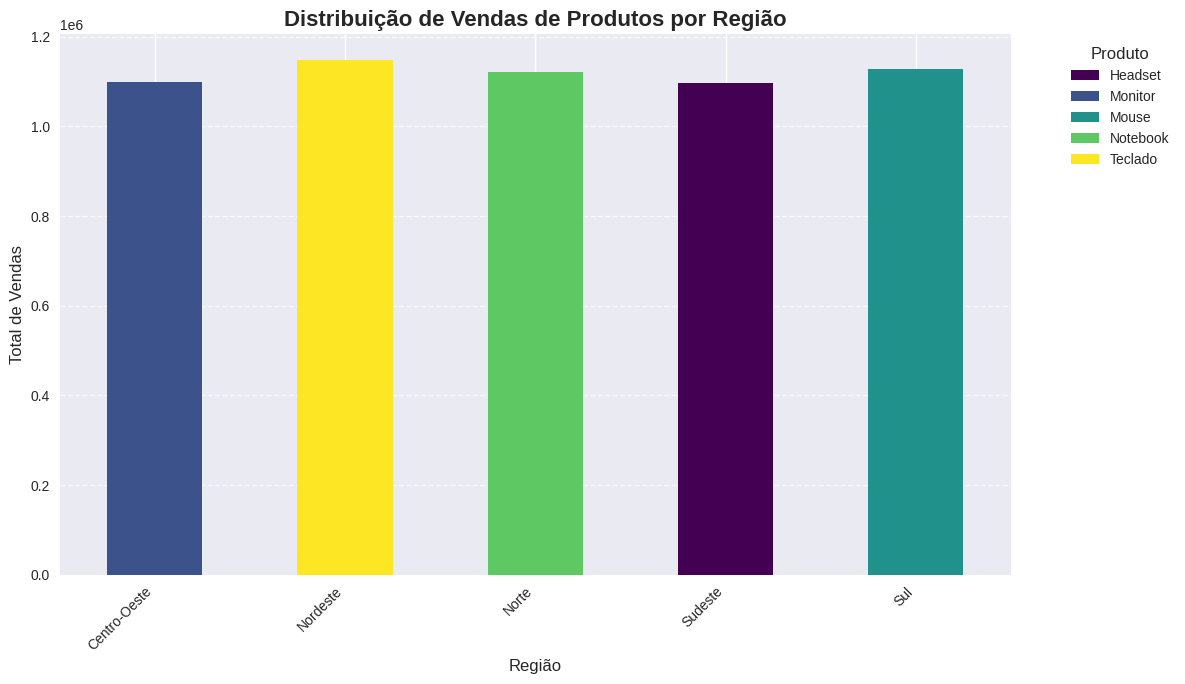


--- Análise Detalhada da Distribuição de Vendas de Produtos por Região ---
✓ Este gráfico de barras empilhadas é fundamental para entender a composição das vendas dentro de cada região.
✓ Ele mostra quais produtos contribuem mais para o total de vendas em cada área geográfica.


In [40]:
# Calcular as vendas de cada produto por região
vendas_produto_regiao = df_vendas_completo.groupby(['Regiao', 'Produto'])['Vendas'].sum().unstack(fill_value=0)

# Plotar o gráfico de barras empilhadas
vendas_produto_regiao.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Distribuição de Vendas de Produtos por Região', fontsize=16, fontweight='bold')
plt.xlabel('Região', fontsize=12)
plt.ylabel('Total de Vendas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Produto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Análise Detalhada da Distribuição de Vendas de Produtos por Região ---")
print("✓ Este gráfico de barras empilhadas é fundamental para entender a composição das vendas dentro de cada região.")
print("✓ Ele mostra quais produtos contribuem mais para o total de vendas em cada área geográfica.")

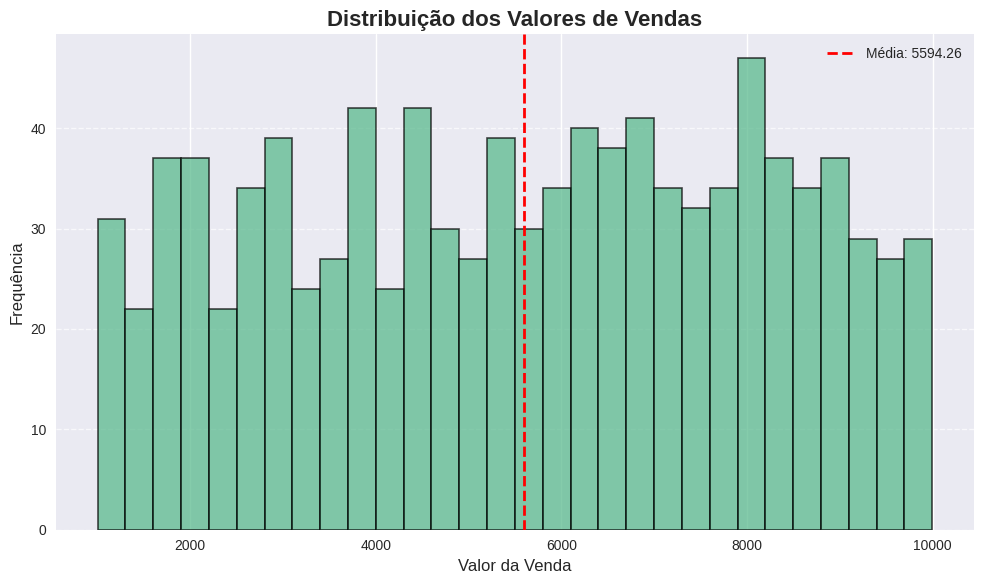


--- Análise do Histograma de Vendas ---
✓ Média das Vendas: 5594.26
✓ Mediana das Vendas: 5750.00
✓ Desvio Padrão das Vendas: 2533.55
✓ Valor Mínimo de Venda: 1004.00
✓ Valor Máximo de Venda: 9996.00

🔍 Observações:
✓ Este histograma mostra a frequência com que diferentes faixas de valores de vendas ocorrem.
✓ A distribuição parece ser relativamente uniforme, indicando que os valores de vendas estão espalhados sem grandes picos em faixas específicas.
✓ A linha vermelha tracejada indica a média geral dos valores de vendas.


In [37]:
# Distribuição dos Valores de Vendas
plt.figure(figsize=(10, 6))

# Criando o histograma da coluna 'Vendas' do df_vendas_completo
plt.hist(df_vendas_completo['Vendas'], bins=30, color='#52B788', alpha=0.7, edgecolor='black', linewidth=1.2)

# Personalizando o gráfico
plt.title('Distribuição dos Valores de Vendas', fontsize=16, fontweight='bold')
plt.xlabel('Valor da Venda', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Adicionando linha da média
media_vendas = df_vendas_completo['Vendas'].mean()
plt.axvline(x=media_vendas, color='red', linestyle='--', linewidth=2, label=f'Média: {media_vendas:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Análise estatística detalhada
print("\n--- Análise do Histograma de Vendas ---")
print(f"✓ Média das Vendas: {df_vendas_completo['Vendas'].mean():.2f}")
print(f"✓ Mediana das Vendas: {df_vendas_completo['Vendas'].median():.2f}")
print(f"✓ Desvio Padrão das Vendas: {df_vendas_completo['Vendas'].std():.2f}")
print(f"✓ Valor Mínimo de Venda: {df_vendas_completo['Vendas'].min():.2f}")
print(f"✓ Valor Máximo de Venda: {df_vendas_completo['Vendas'].max():.2f}")
print("\n🔍 Observações:")
print("✓ Este histograma mostra a frequência com que diferentes faixas de valores de vendas ocorrem.")
print("✓ A distribuição parece ser relativamente uniforme, indicando que os valores de vendas estão espalhados sem grandes picos em faixas específicas.")
print("✓ A linha vermelha tracejada indica a média geral dos valores de vendas.")